In [4]:
import os
from google.colab import drive

# Mount Google Drive
drive.mount("/content/drive")

# Environment-specific dataset path
os.environ["TDF_DATASET_ROOT"] = (
    "/content/drive/MyDrive/UROP_Plant_Disease/"
    "datasets/PlantVillage/plantvillage dataset/color"
)

# Use the environment variable
DATASET_ROOT = os.environ["TDF_DATASET_ROOT"]

print("Dataset root:", DATASET_ROOT)
print("Dataset exists:", os.path.exists(DATASET_ROOT))
if os.path.exists(DATASET_ROOT):
    print("\nDataset folders:")
    for item in sorted(os.listdir(DATASET_ROOT)):
        print(" -", item)
else:
    print("Dataset path not found.")

Mounted at /content/drive
Dataset root: /content/drive/MyDrive/UROP_Plant_Disease/datasets/PlantVillage/plantvillage dataset/color
Dataset exists: True

Dataset folders:
 - Tomato___Bacterial_spot
 - Tomato___Early_blight
 - Tomato___Late_blight
 - Tomato___Leaf_Mold
 - Tomato___Septoria_leaf_spot
 - Tomato___Spider_mites Two-spotted_spider_mite
 - Tomato___Target_Spot
 - Tomato___Tomato_Yellow_Leaf_Curl_Virus
 - Tomato___Tomato_mosaic_virus
 - Tomato___healthy


In [ ]:
import os
from collections import Counter

class_counts = {}

for class_name in sorted(os.listdir(DATASET_ROOT)):
    class_path = os.path.join(DATASET_ROOT, class_name)

    if os.path.isdir(class_path):
        image_files = [
            f for f in os.listdir(class_path)
            if f.lower().endswith((".jpg", ".jpeg", ".png"))
        ]

        class_counts[class_name] = len(image_files)

print("Number of classes:", len(class_counts))
print("\nImages per class:\n")

for class_name, count in class_counts.items():
    print(f"{class_name}: {count}")

Number of classes: 10

Images per class:

Tomato___Bacterial_spot: 2127
Tomato___Early_blight: 1000
Tomato___Late_blight: 1909
Tomato___Leaf_Mold: 952
Tomato___Septoria_leaf_spot: 1771
Tomato___Spider_mites Two-spotted_spider_mite: 1676
Tomato___Target_Spot: 1404
Tomato___Tomato_Yellow_Leaf_Curl_Virus: 5357
Tomato___Tomato_mosaic_virus: 373
Tomato___healthy: 1591


In [ ]:
from PIL import Image
import os
from collections import Counter

image_dimensions = Counter()
total_checked = 0
corrupted_images = []

for class_name in sorted(os.listdir(DATASET_ROOT)):
    class_path = os.path.join(DATASET_ROOT, class_name)

    if not os.path.isdir(class_path):
        continue

    for filename in os.listdir(class_path):

        if not filename.lower().endswith((".jpg", ".jpeg", ".png")):
            continue

        image_path = os.path.join(class_path, filename)

        try:
            with Image.open(image_path) as img:
                image_dimensions[img.size] += 1
                total_checked += 1

        except Exception as e:
            corrupted_images.append(image_path)

print("Total images checked:", total_checked)
print("Unique image dimensions:", len(image_dimensions))

print("\nMost common image dimensions:")
for dimension, count in image_dimensions.most_common(10):
    print(f"{dimension}: {count}")

print("\nCorrupted images:", len(corrupted_images))

Total images checked: 18160
Unique image dimensions: 1

Most common image dimensions:
(256, 256): 18160

Corrupted images: 0


In [ ]:
from collections import Counter
import os

file_extensions = Counter()

for class_name in os.listdir(DATASET_ROOT):
    class_path = os.path.join(DATASET_ROOT, class_name)

    if not os.path.isdir(class_path):
        continue

    for filename in os.listdir(class_path):
        extension = os.path.splitext(filename)[1].lower()

        if extension:
            file_extensions[extension] += 1

print("Image file formats:")
for extension, count in file_extensions.items():
    print(f"{extension}: {count}")

Image file formats:
.jpg: 18159
.jpeg: 1


In [ ]:
import os

SEGMENTED_ROOT = "/content/drive/MyDrive/UROP_Plant_Disease/datasets/PlantVillage/plantvillage dataset/segmented"

print("Segmented dataset exists:", os.path.exists(SEGMENTED_ROOT))

if os.path.exists(SEGMENTED_ROOT):
    print("\nSegmented folders:")

    for item in sorted(os.listdir(SEGMENTED_ROOT)):
        item_path = os.path.join(SEGMENTED_ROOT, item)

        if os.path.isdir(item_path):
            files = [
                f for f in os.listdir(item_path)
                if f.lower().endswith((".jpg", ".jpeg", ".png"))
            ]

            print(f"{item}: {len(files)} images")

Segmented dataset exists: True

Segmented folders:
Tomato___Bacterial_spot: 2133 images
Tomato___Early_blight: 1000 images
Tomato___Late_blight: 1909 images
Tomato___Leaf_Mold: 952 images
Tomato___Septoria_leaf_spot: 1771 images
Tomato___Spider_mites Two-spotted_spider_mite: 1676 images
Tomato___Target_Spot: 1404 images
Tomato___Tomato_Yellow_Leaf_Curl_Virus: 5358 images
Tomato___Tomato_mosaic_virus: 373 images
Tomato___healthy: 1591 images


Color image: 004cbe60-8ff9-4965-92df-e86694d5e9ba___RS_Erly.B 8253.JPG
Segmented image: 04e38351-80bc-4260-8a4d-187f7817c3e5___RS_Erly.B 7439_final_masked.jpg
Color size: (256, 256)
Segmented size: (256, 256)


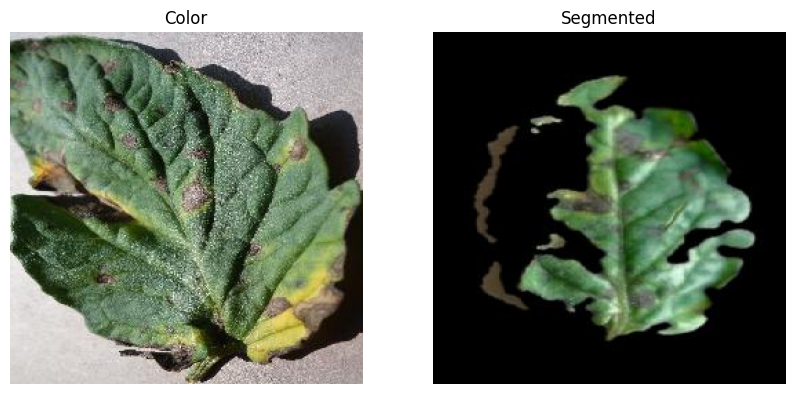

In [ ]:
from PIL import Image
import matplotlib.pyplot as plt
import os

class_name = "Tomato___Early_blight"

color_class_path = os.path.join(DATASET_ROOT, class_name)

segmented_class_path = os.path.join(
    SEGMENTED_ROOT,
    class_name
)

color_image = next(
    f for f in os.listdir(color_class_path)
    if f.lower().endswith((".jpg", ".jpeg", ".png"))
)

segmented_image = next(
    f for f in os.listdir(segmented_class_path)
    if f.lower().endswith((".jpg", ".jpeg", ".png"))
)

color_path = os.path.join(color_class_path, color_image)
segmented_path = os.path.join(segmented_class_path, segmented_image)

color_img = Image.open(color_path)
segmented_img = Image.open(segmented_path)

print("Color image:", color_image)
print("Segmented image:", segmented_image)
print("Color size:", color_img.size)
print("Segmented size:", segmented_img.size)

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(color_img)
plt.title("Color")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(segmented_img)
plt.title("Segmented")
plt.axis("off")

plt.show()

In [ ]:
import os
import hashlib
from collections import defaultdict

DATASET_ROOT = "/content/drive/MyDrive/UROP_Plant_Disease/datasets/PlantVillage/plantvillage dataset/color"

hash_to_files = defaultdict(list)

for class_name in sorted(os.listdir(DATASET_ROOT)):
    class_path = os.path.join(DATASET_ROOT, class_name)

    if not os.path.isdir(class_path):
        continue

    for filename in os.listdir(class_path):

        if not filename.lower().endswith((".jpg", ".jpeg", ".png")):
            continue

        image_path = os.path.join(class_path, filename)

        with open(image_path, "rb") as f:
            file_hash = hashlib.md5(f.read()).hexdigest()

        hash_to_files[file_hash].append(image_path)

duplicate_groups = {
    h: files
    for h, files in hash_to_files.items()
    if len(files) > 1
}

print("Total images:", sum(len(v) for v in hash_to_files.values()))
print("Unique file contents:", len(hash_to_files))
print("Exact duplicate groups:", len(duplicate_groups))
print("Images involved in exact duplicates:",
      sum(len(v) for v in duplicate_groups.values()))

Total images: 18160
Unique file contents: 18146
Exact duplicate groups: 14
Images involved in exact duplicates: 28


In [ ]:
!pip -q install ImageHash

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.7/296.7 kB 3.3 MB/s eta 0:00:00


In [ ]:
import os
import imagehash
from PIL import Image

image_hashes = []

for class_name in sorted(os.listdir(DATASET_ROOT)):
    class_path = os.path.join(DATASET_ROOT, class_name)

    if not os.path.isdir(class_path):
        continue

    for filename in os.listdir(class_path):

        if not filename.lower().endswith((".jpg", ".jpeg", ".png")):
            continue

        image_path = os.path.join(class_path, filename)

        try:
            with Image.open(image_path) as img:
                phash = imagehash.phash(img)

            image_hashes.append((phash, image_path))

        except Exception:
            pass

print("Images hashed:", len(image_hashes))

Images hashed: 18160


In [ ]:
near_duplicates = []

for i in range(len(image_hashes)):
    hash1, path1 = image_hashes[i]

    for j in range(i + 1, len(image_hashes)):
        hash2, path2 = image_hashes[j]

        distance = hash1 - hash2

        if distance <= 4:
            near_duplicates.append(
                (distance, path1, path2)
            )

print("Near-duplicate pairs:", len(near_duplicates))

Near-duplicate pairs: 66


In [ ]:
for group_num, (file_hash, files) in enumerate(duplicate_groups.items(), start=1):
    print(f"\nDuplicate Group {group_num}")
    for path in files:
        print(" ", path)


Duplicate Group 1
  /content/drive/MyDrive/UROP_Plant_Disease/datasets/PlantVillage/plantvillage dataset/color/Tomato___Late_blight/1a69b38b-c4eb-42c4-9584-bcb14fb8db0c___GHLB2 Leaf 9011.JPG
  /content/drive/MyDrive/UROP_Plant_Disease/datasets/PlantVillage/plantvillage dataset/color/Tomato___Late_blight/2c47b891-3c97-48f1-a2cc-5aa53d3a1148___GHLB2 Leaf 9011.JPG

Duplicate Group 2
  /content/drive/MyDrive/UROP_Plant_Disease/datasets/PlantVillage/plantvillage dataset/color/Tomato___Late_blight/3fae9c64-18f0-4a67-9f97-554248bb1bed___GHLB_PS Leaf 24 Day 16.jpg
  /content/drive/MyDrive/UROP_Plant_Disease/datasets/PlantVillage/plantvillage dataset/color/Tomato___Late_blight/5de6da85-f8c4-48c4-b463-3e6bd78884cc___GHLB_PS Leaf 24 Day 16.jpg

Duplicate Group 3
  /content/drive/MyDrive/UROP_Plant_Disease/datasets/PlantVillage/plantvillage dataset/color/Tomato___Late_blight/48c55974-9fe9-4f4b-94f7-c8cd127d1e05___GHLB_PS Leaf 23.7 Day 13.jpg
  /content/drive/MyDrive/UROP_Plant_Disease/datasets/Pl

In [ ]:
from collections import Counter

# Summarize near-duplicate pairs by class
class_pair_counts = Counter()
cross_class_pairs = []

for distance, path1, path2 in near_duplicates:

    class1 = path1.split("/")[-2]
    class2 = path2.split("/")[-2]

    if class1 == class2:
        class_pair_counts[class1] += 1
    else:
        cross_class_pairs.append(
            (distance, class1, class2, path1, path2)
        )

print("Total near-duplicate pairs:", len(near_duplicates))

print("\nNear-duplicate pairs within the same class:")
for class_name, count in class_pair_counts.items():
    print(f"{class_name}: {count}")

print("\nCross-class near-duplicate pairs:", len(cross_class_pairs))

if cross_class_pairs:
    print("\nCross-class pairs:")
    for pair in cross_class_pairs:
        distance, class1, class2, path1, path2 = pair
        print(f"\nDistance: {distance}")
        print(f"{class1} -> {path1}")
        print(f"{class2} -> {path2}")

Total near-duplicate pairs: 66

Near-duplicate pairs within the same class:
Tomato___Bacterial_spot: 5
Tomato___Late_blight: 9
Tomato___Leaf_Mold: 1
Tomato___Spider_mites Two-spotted_spider_mite: 5
Tomato___Tomato_Yellow_Leaf_Curl_Virus: 28
Tomato___Tomato_mosaic_virus: 1
Tomato___healthy: 13

Cross-class near-duplicate pairs: 4

Cross-class pairs:

Distance: 4
Tomato___Bacterial_spot -> /content/drive/MyDrive/UROP_Plant_Disease/datasets/PlantVillage/plantvillage dataset/color/Tomato___Bacterial_spot/5d1f3889-f029-4ebd-834d-9e39d775b070___GCREC_Bact.Sp 5996.JPG
Tomato___Tomato_Yellow_Leaf_Curl_Virus -> /content/drive/MyDrive/UROP_Plant_Disease/datasets/PlantVillage/plantvillage dataset/color/Tomato___Tomato_Yellow_Leaf_Curl_Virus/6c74c99f-0377-4870-ac98-c1ad619d8a7a___YLCV_GCREC 2623.JPG

Distance: 4
Tomato___Leaf_Mold -> /content/drive/MyDrive/UROP_Plant_Disease/datasets/PlantVillage/plantvillage dataset/color/Tomato___Leaf_Mold/fcfc6758-32cd-4e18-8d56-e3ffde988921___Crnl_L.Mold 6591.

In [ ]:
from collections import Counter

distance_counts = Counter(
    distance for distance, _, _ in near_duplicates
)

print("Perceptual hash distance distribution:")

for distance in sorted(distance_counts):
    print(f"Distance {distance}: {distance_counts[distance]} pairs")

Perceptual hash distance distribution:
Distance 0: 14 pairs
Distance 2: 8 pairs
Distance 4: 44 pairs


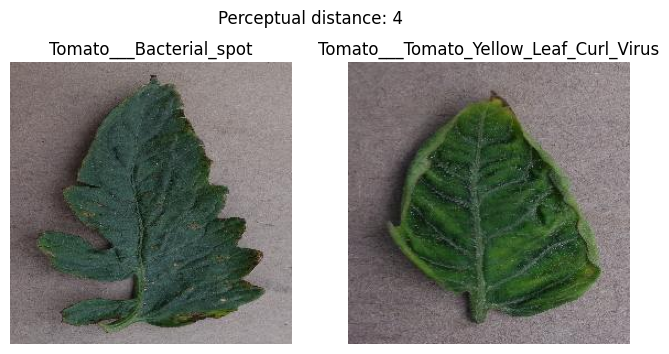

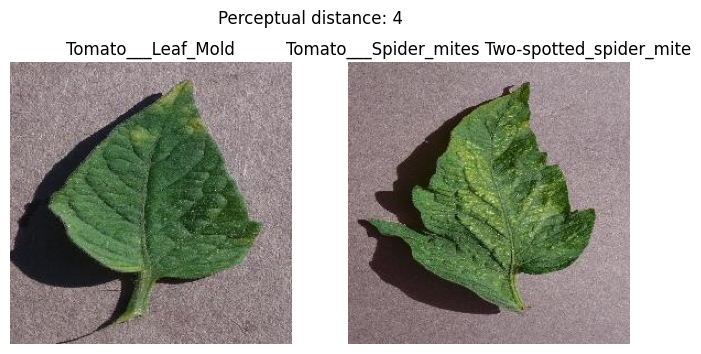

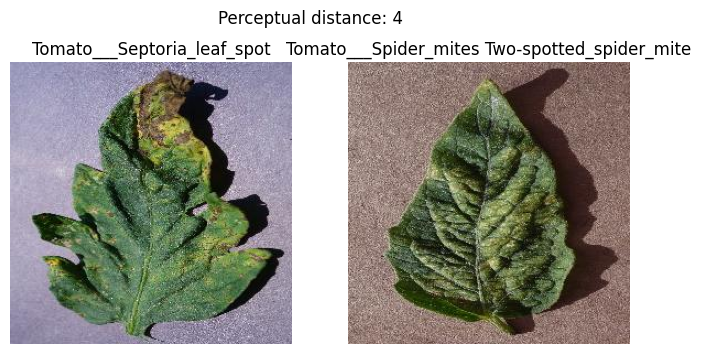

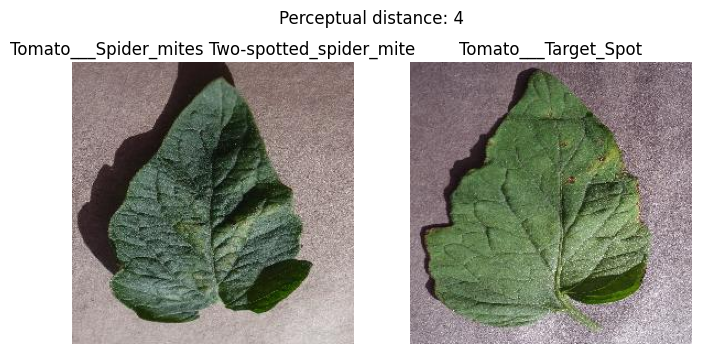

In [ ]:
import matplotlib.pyplot as plt
from PIL import Image

for distance, class1, class2, path1, path2 in cross_class_pairs:

    img1 = Image.open(path1)
    img2 = Image.open(path2)

    plt.figure(figsize=(8, 4))

    plt.subplot(1, 2, 1)
    plt.imshow(img1)
    plt.title(class1)
    plt.axis("off")

    plt.subplot(1, 2, 2)
    plt.imshow(img2)
    plt.title(class2)
    plt.axis("off")

    plt.suptitle(f"Perceptual distance: {distance}")
    plt.show()

In [5]:
import sys
import torch
import torchvision
import numpy
import pandas
import sklearn
import PIL
import yaml

print("Python:", sys.version)
print("PyTorch:", torch.__version__)
print("Torchvision:", torchvision.__version__)
print("NumPy:", numpy.__version__)
print("Pandas:", pandas.__version__)
print("Scikit-learn:", sklearn.__version__)
print("Pillow:", PIL.__version__)
print("PyYAML:", yaml.__version__)

Python: 3.13.15 (main, Aug  6 2026, 11:06:22) [GCC 13.3.0]
PyTorch: 2.11.0+cpu
Torchvision: 0.26.0+cpu
NumPy: 2.1.3
Pandas: 2.2.3
Scikit-learn: 1.6.1
Pillow: 11.3.0
PyYAML: 6.0.3


In [6]:
!git clone https://github.com/parnikaaa06/tomato-disease-framework.git

Cloning into 'tomato-disease-framework'...
remote: Enumerating objects: 61, done.
remote: Counting objects: 100% (61/61), done.
remote: Compressing objects: 100% (50/50), done.
remote: Total 61 (delta 0), reused 61 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (61/61), 13.60 KiB | 696.00 KiB/s, done.


In [12]:
%cd /content/tomato-disease-framework/tomato_disease_framework

/content/tomato-disease-framework/tomato_disease_framework


In [13]:
!ls

app	     data	     knowledge_base  README.md	       tests
configs      evaluation      models	     requirements.txt  training
config.yaml  explainability  preprocessing   scripts	       vlm


In [14]:
%pip install -r requirements.txt

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 33.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 46.3 MB/s eta 0:00:00


In [17]:
from scripts.config_loader import load_config

c = load_config()

print("Configured dataset path:")
print(c["data"]["external_dataset_path"])

Configured dataset path:
/content/drive/MyDrive/UROP_Plant_Disease/datasets/PlantVillage/plantvillage dataset/color


After that, don't clone again every time.

Use:

%cd /content/tomato-disease-framework
!git pull origin main